In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 6.8 MB/s  0:01:29m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 4.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 6.3 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [tensorflow]2 [tensorflow]


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import joblib
import json

In [88]:
train_path = "dataset/inventaris/train.csv"
test_path = "dataset/inventaris/test.csv"

In [89]:
df_train = pd.read_csv(train_path, parse_dates=['date']) 
df_test = pd.read_csv(test_path, parse_dates=['date'])

In [90]:
df_test.head(5)

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [91]:
df_train.head(5)

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [92]:
print("\nStruktur Data Train : \n")
df_train.info()
print("\nStruktur Data Test : \n")
df_test.info()


Struktur Data Train : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB

Struktur Data Test : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   id      45000 non-null  int64         
 1   date    45000 non-null  datetime64[ns]
 2   store   45000 non-null  int64         
 3   item    45000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.4 MB


In [93]:
df_train = pd.read_csv(train_path, parse_dates=['date'])
df_test = pd.read_csv(test_path, parse_dates=['date'])
df_train = df_train.sort_values(['store', 'item', 'date']).reset_index(drop=True)

def add_lag_features(df):
    data = df.sort_values(['store', 'item', 'date']).copy()
    group_sales = data.groupby(['store', 'item'])['sales']

    for lag in (1, 2, 3, 7, 14, 30):
        data[f'sales_lag_{lag}'] = group_sales.shift(lag)

    for window in (7, 14, 30):
        data[f'sales_roll_mean_{window}'] = group_sales.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )

    data['sales_ewma_7'] = group_sales.transform(
        lambda x: x.shift(1).ewm(span=7, min_periods=1).mean()
    )
    data['sales_ewma_30'] = group_sales.transform(
        lambda x: x.shift(1).ewm(span=30, min_periods=1).mean()
    )

    data['month'] = data['date'].dt.month.astype('int8')
    data['day_of_week'] = data['date'].dt.dayofweek.astype('int8')
    data['day_of_month'] = data['date'].dt.day.astype('int8')
    data['quarter'] = data['date'].dt.quarter.astype('int8')
    return data

df_train_feat = add_lag_features(df_train)

In [94]:
FEATURES = [
    'month', 'day_of_week', 'day_of_month', 'quarter',
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_30',
    'sales_roll_mean_7', 'sales_roll_mean_14', 'sales_roll_mean_30',
    'sales_ewma_7', 'sales_ewma_30',
]

df_model = df_train_feat.dropna().reset_index(drop=True)
train_mask = df_model['date'] < '2017-01-01'
val_mask = df_model['date'].between('2017-01-01', '2017-12-31')

X_train = df_model.loc[train_mask, FEATURES]
y_train = df_model.loc[train_mask, 'sales']
X_val = df_model.loc[val_mask, FEATURES]
y_val = df_model.loc[val_mask, 'sales']

model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)

print('Train rows:', len(X_train))
print('Validation rows:', len(X_val))

Train rows: 715500
Validation rows: 182500


In [95]:
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print('\nEVALUATION MODEL :')
print(f'R-squared (R2 Score): {r2:.4f}')
print(f'MAE (Mean Absolute Error): {mae:.2f}')
print(f'RMSE (Root Mean Squared Error): {rmse:.2f}')

assert r2 > 0.80, f'R2 masih di bawah target: {r2:.4f}'


EVALUATION MODEL :
R-squared (R2 Score): 0.9313
MAE (Mean Absolute Error): 6.34
RMSE (Root Mean Squared Error): 8.27


,feature,importance
10,sales_roll_mean_7,0.587026
7,sales_lag_7,0.211055
11,sales_roll_mean_14,0.119286
13,sales_ewma_7,0.027932
1,day_of_week,0.022827
8,sales_lag_14,0.016035
4,sales_lag_1,0.006729
0,month,0.003159
2,day_of_month,0.001997
12,sales_roll_mean_30,0.001474


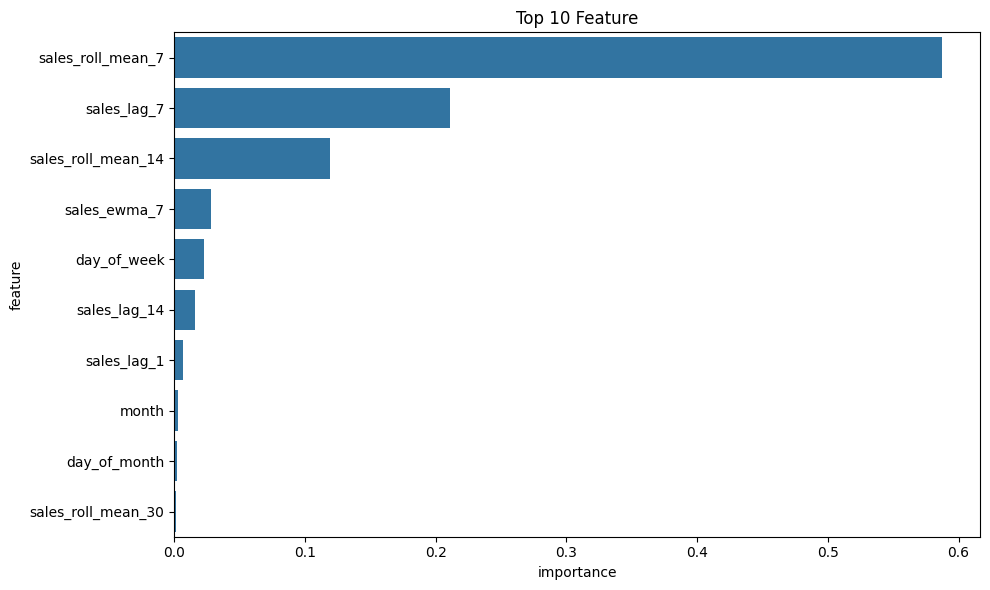

In [96]:
feature_importance = (
    pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_})
    .sort_values('importance', ascending=False)
)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature')
plt.tight_layout()
plt.show()

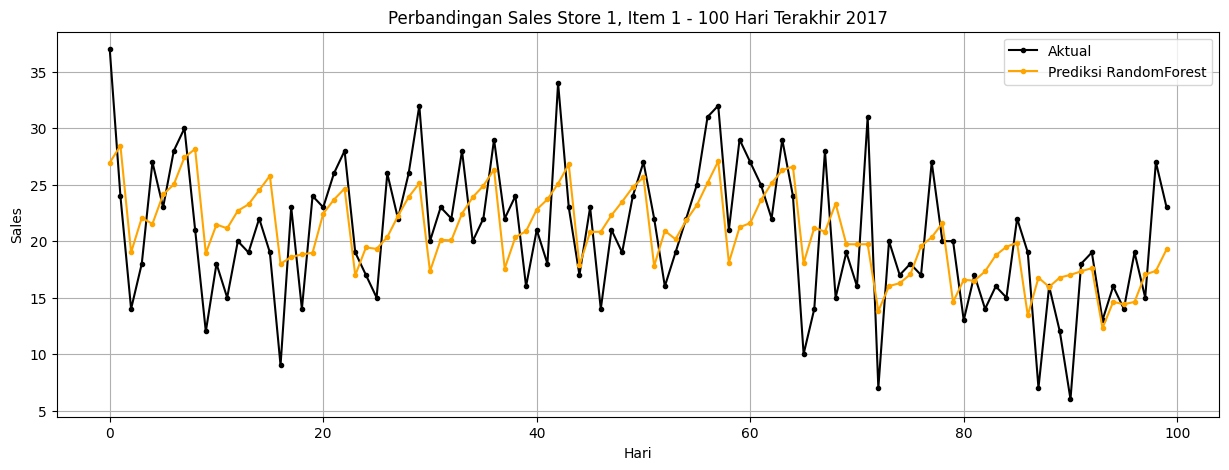

In [79]:
sample_store = 1
sample_item = 1
sample_mask = (
    (df_model['date'].between('2017-01-01', '2017-12-31')) &
    (df_model['store'] == sample_store) &
    (df_model['item'] == sample_item)
)

sample_actual = df_model.loc[sample_mask, 'sales'].to_numpy()
sample_pred = model.predict(df_model.loc[sample_mask, FEATURES])

plt.figure(figsize=(15, 5))
plt.plot(sample_actual[-100:], label='Aktual', marker='.', color='black')
plt.plot(sample_pred[-100:], label='Prediksi RandomForest', marker='.', color='orange')
plt.title(f'Perbandingan Sales Store {sample_store}, Item {sample_item} - 100 Hari Terakhir 2017')
plt.xlabel('Hari')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [97]:
model.fit(df_model[FEATURES], df_model['sales'])

artifact = {
    "model": model,
    "features": FEATURES,
    "history_days": 90,
    "revision": 1,
    "description": "RandomForest daily inventory sales forecast"
}
joblib.dump(artifact, "models/model_inventaris.pkl")

with open("models/model_inventaris_meta.json", "w") as f:
    json.dump({
        "features": FEATURES,
        "history_days": 90,
        "revision": 1,
        "description": "RandomForest daily inventory sales forecast"
    }, f, indent=2)

print("Model saved to models/model_inventaris.pkl")
print("Metadata saved to models/model_inventaris_meta.json")

Model saved to models/model_inventaris.pkl
Metadata saved to models/model_inventaris_meta.json


## Input Model

Model `model_full` menerima **satu baris fitur** per kombinasi `(store, item, date)`.

`store` dan `item` tidak masuk langsung ke `model.predict(...)`. Keduanya dipakai sebagai kunci untuk mengambil histori sales barang yang sama, lalu histori tersebut diubah menjadi fitur lag, rolling mean, dan EWMA.

| # | Data dari Backend/API | Tipe | Deskripsi | Cara Mendapatkan |
|---|------------------------|------|-----------|------------------|
| 1 | `date` | date/string | Tanggal yang ingin diprediksi | Request dari backend |
| 2 | `store` | int/string | ID toko/cabang | Database toko |
| 3 | `item` | int/string | ID produk/SKU/barcode | Database produk |
| 4 | `sales_history` | array angka | Riwayat sales harian untuk pasangan `store × item` yang sama | Query transaksi harian dari database |

Minimal histori:

| Kebutuhan | Jumlah Hari |
|---|---:|
| Minimum agar semua lag tersedia | 30 hari |
| Rekomendasi produksi | 90 hari |

Fitur yang harus dibentuk sebelum masuk ke model:

| # | Fitur | Tipe | Deskripsi | Cara Hitung |
|---|-------|------|-----------|------------|
| 1 | `month` | int | Bulan prediksi | `date.month` |
| 2 | `day_of_week` | int | Hari, 0=Senin dan 6=Minggu | `date.dayofweek` |
| 3 | `day_of_month` | int | Tanggal dalam bulan | `date.day` |
| 4 | `quarter` | int | Kuartal tahun | `date.quarter` |
| 5 | `sales_lag_1` | float | Sales 1 hari sebelumnya | `sales_history[-1]` |
| 6 | `sales_lag_2` | float | Sales 2 hari sebelumnya | `sales_history[-2]` |
| 7 | `sales_lag_3` | float | Sales 3 hari sebelumnya | `sales_history[-3]` |
| 8 | `sales_lag_7` | float | Sales 7 hari sebelumnya | `sales_history[-7]` |
| 9 | `sales_lag_14` | float | Sales 14 hari sebelumnya | `sales_history[-14]` |
| 10 | `sales_lag_30` | float | Sales 30 hari sebelumnya | `sales_history[-30]` |
| 11 | `sales_roll_mean_7` | float | Rata-rata sales 7 hari terakhir | `mean(sales_history[-7:])` |
| 12 | `sales_roll_mean_14` | float | Rata-rata sales 14 hari terakhir | `mean(sales_history[-14:])` |
| 13 | `sales_roll_mean_30` | float | Rata-rata sales 30 hari terakhir | `mean(sales_history[-30:])` |
| 14 | `sales_ewma_7` | float | Exponential weighted mean span 7 | Hitung dari histori |
| 15 | `sales_ewma_30` | float | Exponential weighted mean span 30 | Hitung dari histori |

Urutan kolom harus sama persis dengan variabel `FEATURES` di notebook.


## Alur Trigger Model

```text
┌─────────────────────────────────────────────────────────┐
│  1. REQUEST PREDIKSI DARI BACKEND                       │
│     Backend mengirim store, item, dan tanggal prediksi   │
└──────────────────────┬──────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────┐
│  2. AMBIL HISTORI SALES                                 │
│     Query database untuk sales harian store × item       │
│     Ambil minimal 30 hari, rekomendasi 90 hari terakhir  │
└──────────────────────┬──────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────┐
│  3. EKSTRAK FITUR                                       │
│     Hitung fitur kalender, lag, rolling mean, dan EWMA   │
│     Urutan fitur wajib sama dengan FEATURES notebook     │
└──────────────────────┬──────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────┐
│  4. PREDIKSI                                            │
│     model.predict(X_new)                                │
│     → predicted_sales                                   │
└──────────────────────┬──────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────┐
│  5. SAVED                                               │
│     Simpan hasil prediksi atau langsung return JSON     │
│     Backend membandingkan dengan stok tersedia          │
└──────────────────────┬──────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────┐
│  6. REKOMENDASI RESTOCK                                 │
│     Jika predicted_sales > stok aman, buat alert restock│
└─────────────────────────────────────────────────────────┘
```

**Contoh:**

| Step | Data |
|------|------|
| Request backend | `store="TOKO-001"`, `item="SKU-BERAS-5KG"`, `date="2026-08-01"` |
| Query histori | Ambil sales harian 90 hari terakhir untuk toko dan SKU tersebut |
| Ekstrak fitur | Hitung lag 1/2/3/7/14/30, rolling mean, EWMA, dan fitur kalender |
| Prediksi model | `predicted_sales = 42` |
| Keputusan backend | Jika stok tersedia 25 dan safety stock 10, maka perlu restock |


## Output Model

Output utama model adalah `predicted_sales`, yaitu estimasi jumlah unit yang akan terjual pada tanggal prediksi.

Format respons untuk satu barang:

```json
{
  "date": "2026-08-01",
  "store": "TOKO-001",
  "item": "SKU-BERAS-5KG",
  "predicted_sales": 42
}
```

Format respons untuk banyak barang:

```json
[
  {"date": "2026-08-01", "store": "TOKO-001", "item": "SKU-BERAS-5KG", "predicted_sales": 42},
  {"date": "2026-08-01", "store": "TOKO-001", "item": "SKU-GULA-1KG", "predicted_sales": 18}
]
```

Nilai `predicted_sales` harus dibulatkan menjadi integer dan tidak boleh negatif.


Model **tidak perlu menerima semua transaksi mentah**. cukup mengirim tanggal, store, item, dan histori sales harian yang sudah diagregasi.

Rekomendasi penyimpanan data:

| Data | Simpan di Database? | Dipakai Saat Prediksi? |
|---|---|---|
| Semua transaksi mentah | Ya | Untuk audit dan agregasi ulang |
| Sales harian per store × item | Ya | Ya, ini input utama histori |
| 90 hari sales terakhir | Bisa cache | Ya, agar API cepat |

Jika barang baru belum punya histori:

| Kondisi | Perlakuan |
|---|---|
| Histori < 30 hari | Jangan pakai model ini sebagai keputusan utama |
| Histori 30–89 hari | Bisa diprediksi, tapi kurang stabil |
| Histori ≥ 90 hari | Ideal untuk pipeline ini |

Untuk barang baru, backend sebaiknya memakai aturan bisnis sementara, misalnya minimum stock manual, sampai histori sales cukup.